In [1]:
import bldw
import numpy as np
import blimpy as bl
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import setigen as stg
from astropy import units as u
import h5py
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

numexpr.utils   INFO     Note: NumExpr detected 40 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
numexpr.utils   INFO     NumExpr defaulting to 8 threads.


In [64]:
target = 'HIP85042'
f1 = 1435.942708
f2 = 1439.067720
print(f2-f1)
freq = f1-1*(f2-f1)
ws = 10000e-6 # MHz
mjd = 57898

3.1250119999999697


In [54]:
df = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/BL_cadences_unique_nearby_star_sample_only.csv')
dff = df.iloc[np.where((df['Receiver'].values=='Rcvr1_2')&(df['Target'].values==target))]
dff = df.iloc[np.where(df['Receiver'].values=='Rcvr1_2')]
useful_h5s = dff['.h5 path 1'].values
h5_mjds = np.array([int(h5.split('guppi_')[1][:5]) for h5 in useful_h5s])
dff0 = dff.iloc[np.where(h5_mjds==mjd)]
dff0

,Target,RA,DEC,Distance (pc),Cadence ID,Cadence Type,Receiver,Vmag,Spectral Type,.h5 path 1,...,.h5 path 3,.h5 path 4,.h5 path 5,.h5 path 6,.dat path 1,.dat path 2,.dat path 3,.dat path 4,.dat path 5,.dat path 6
22146,HIP53985,11 2 38.5,21 58 0,11.6,2399,ABACAD,Rcvr1_2,9.57,K,/datag/pipeline/AGBT16A_999_182/holding/splice...,...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...
22147,HIP54872,11 14 6.66,20 31 23,17.6,2411,ABACAD,Rcvr1_2,2.56,A4V,/datag/pipeline/AGBT16A_999_182/holding/splice...,...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...
22647,HIP54677,11 11 33.8,-14 59 38,22.7,2405,ABACAD,Rcvr1_2,9.06,K4V,/datag/pipeline/AGBT16A_999_182/holding/splice...,...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...
22757,HIP54906,11 14 33.0,25 42 38,21.2,2417,ABACAD,Rcvr1_2,7.76,K1V,/datag/pipeline/AGBT16A_999_182/holding/splice...,...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datag/pipeline/AGBT16A_999_182/holding/splice...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...,/datax/scratch/benjb/bl_nearby_stars/seticore_...


In [55]:
for i in dff0['.h5 path 1'].values:
    print(i)

/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_06643_HIP53985_0003.gpuspec.0000.h5
/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_11190_HIP54872_0015.gpuspec.0000.h5
/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_08789_HIP54677_0009.gpuspec.0000.h5
/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_13252_HIP54906_0021.gpuspec.0000.h5


/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_08789_HIP54677_0009.gpuspec.0000.h5
/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_09209_HIP53759_0010.gpuspec.0000.h5
/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_09628_HIP54677_0011.gpuspec.0000.h5
/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_10032_HIP53820_0012.gpuspec.0000.h5
/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_10436_HIP54677_0013.gpuspec.0000.h5
/datag/pipeline/AGBT16A_999_182/holding/spliced_blc0001020304050607_guppi_57517_10836_HIP53839_0014.gpuspec.0000.h5


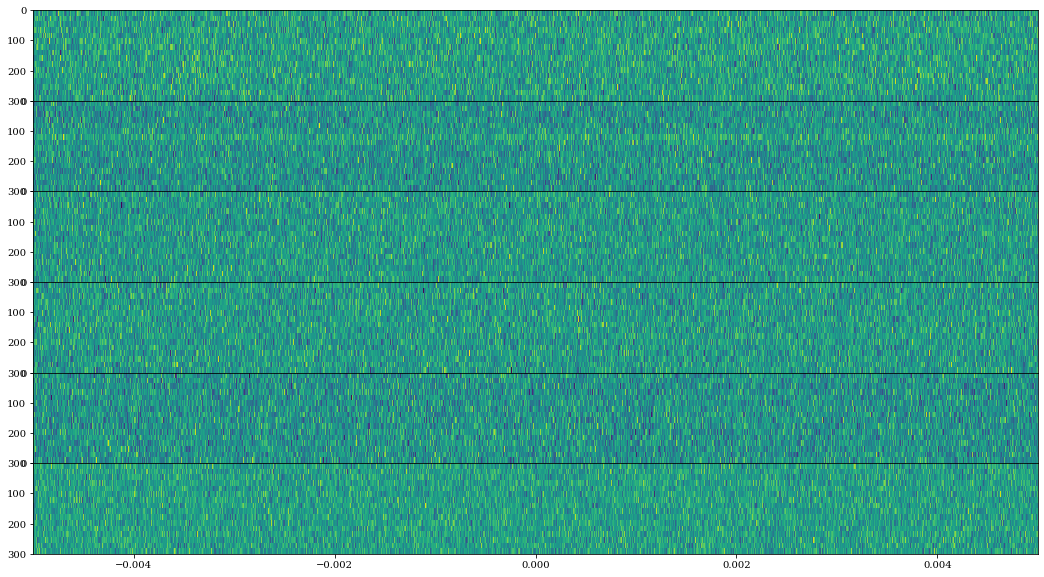

In [61]:
fig, ax = plt.subplots(6, 1, figsize=(18,10))

for i in range(6):
    #print(i+1)
    h5 = dff0[f'.h5 path {i+1}'].values[2]
    print(h5)
    fb = bl.Waterfall(h5, f_start=freq-ws/2, f_stop=freq+ws/2)
    data = np.squeeze(fb.data)
    ax[i].imshow(np.log10(data), aspect='auto', interpolation='none', extent=[-ws/2, ws/2, 300, 0])

plt.subplots_adjust(hspace=0)
plt.savefig(f'test_HIP54677_{freq}.png', bbox_inches='tight')
plt.show()

In [65]:
from astropy.time import Time

mjdf = mjd+.34295

# Convert to Julian Date
jd = mjdf + 2400000.5

# Convert to astropy Time object
t = Time(jd, format='jd')

# Convert to datetime
utc = t.to_datetime()
print(utc)

2017-05-25 08:13:50.879997


In [66]:
print(mjd)

57898
